In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
def read_file(fname, thr_len=0):
    data = []
    with open(fname) as f:
        for x in f:
            line = np.array([float(n) for n in x.split(", ")])
            if len(line)>thr_len:
                data.append(line)
    return data

In [3]:
def pdie(mu,ni,N_HK):
    """probability of a cell dying"""
    return 1-(1-ni*mu)**N_HK
def pmut(mu,ni,N_I,chroms=2):
    """probability of a cell mutating a not-expressed I gene"""
    return 1-(1-ni*mu)**(chroms*(N_I-ni))

In [4]:
def dp(p,r,d,mu,dt,N_HK,chroms):
    """
    Differential equation for the model
    The system is considered to be at stationarity for reproduction rate and HK genes mutation
    """
    n = len(p)
    ### Variations ###
    dp1 = r*p[0]-r*p[0]*pdie(mu,1,N_HK)-r*p[0]*pmut(mu,1,n,chroms)  #1 I gene mutated
    dpi = [ r*p[i]+r*p[i-1]*pmut(mu,i,n,chroms)-r*p[i]*pdie(mu,i+1,N_HK)-r*p[i]*pmut(mu,i+1,n,chroms) for i in range(1,n-1)]
    dpn = r*p[-1]+r*p[-2]*pmut(mu,n-1,n,chroms)-r*p[-1]*pdie(mu,n,N_HK) #all I genes mutated
    #dpd = np.sum([r*d*pdie(mu,i+1,n)*p[i] for i in range(n)])-r*p[-1]
    
    dpis = np.concatenate([[dp1],dpi,[dpn]])
    phi = np.sum(dpis)  # Constant for dilution to keep sum(p)=1
    
    d_tot = np.array([dpis[i]-p[i]*phi for i in range(len(p))])
    return d_tot*dt

In [5]:
### Error areas y ###
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = np.empty(n, dtype=float)
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = arr.mean()
            stds[i] = arr.std(ddof=0)  # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds[i] = np.nan
            
    return means, stds


def plot_stats_elementwise(y, ax, x=None, discard_time=0, label="", color="C0", lw=3, alpha=0.3):
    means, stds = stats_elementwise(y)
    means = means[:len(means)-discard_time]
    stds = stds[:len(stds)-discard_time]
    print(means.shape)
    print(stds.shape)
    
    if x is None:
        x = np.arange(len(means)-discard_time)
    else:
        x = x[:len(x)-discard_time]
    print(x.shape)
    ax.plot(x, means, color=color, lw=lw, label=label)
    ax.fill_between(x, means-stds, means+stds, color=color, alpha=alpha)

In [6]:
### Data for population distribution ###
counts = np.loadtxt("data/counts.txt", delimiter=",", dtype=float)
counts[:,1] = counts[:,1]/sum(counts[:,1])
counts = counts[np.argsort(counts[:, 1])]

### Mu progression ###
mus = read_file("../Data/CancerEvo/0ch_mu.txt")
states = np.loadtxt("../Data/CancerEvo/0ch_state.txt", dtype=str)
mu_tumor = [mus[i] for i in np.where(states=="Tumor")[0]]

FileNotFoundError: data/counts.txt not found.

In [9]:
mu=0.015
r=0.3
N=10
N_HK=10
chroms=1

### Initial conditions ###
dps=0.02
p_init = [0,1,0,0,0,0,0,0,0,0]#[1-dps*(N-1)]+[dps]*(N-1)

dt=0.01
nsteps = 25000

savefig=True
namefig="images/fig5.png"

NameError: name 'counts' is not defined

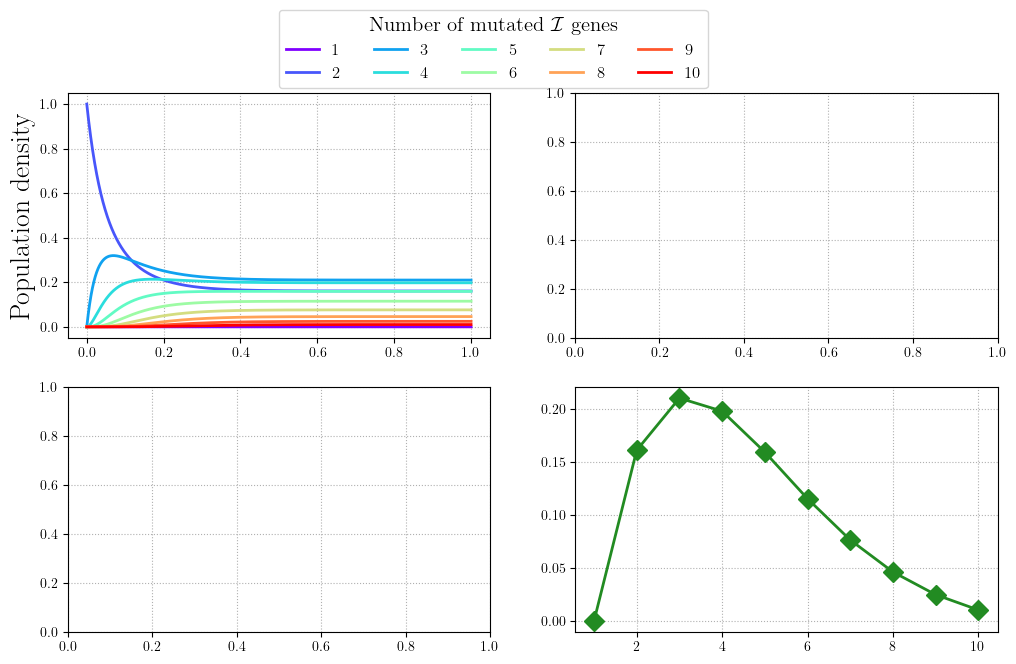

In [10]:
p_list = []
p = np.copy(p_init)
p_list.append(p)

### Simulation ###

for i in range(nsteps):
    dpi = dp(p,r=r,mu=mu,d=1,dt=dt, N_HK=N_HK, chroms=chroms)
    p = p+dpi
    p_list.append(p)
p_list = np.array(p_list)
### Mu computed over time ###
mu_progr = np.array([np.sum(np.array(p*np.arange(1,N+1))*mu) for p in p_list])

from matplotlib import colormaps


cmap = colormaps.get_cmap("rainbow")
colors = [cmap(i / (N - 1)) for i in range(N)]

### Plots ###
_,ax = plt.subplots(2,2,figsize=(12,7))
ax = ax.flatten()
[axi.grid(ls=":") for axi in ax]

### 0) population density over time
for i in range(N):
    ax[0].plot(p_list[:,i],label=str(i+1), c=colors[i], lw=2)
ax[0].legend(loc=[0.5,1.02], ncols=5, title="Number of mutated $\mathcal{I}$ genes", title_fontsize=15, fontsize=12)
#ax[0].set_xlabel("Time", fontsize=15)
ax[0].set_ylabel("Population density", fontsize=20)
ax[0].set_xticks(np.linspace(0,nsteps+1,6), labels=np.arange(6)/5)

### 1) population distribution in the final moment, data vs prediction
#ax[3].scatter(np.arange(1,N+1), p_list[-1], color="k", marker="X", s=150, lw=0.5, label="Model")
ax[3].plot(np.arange(1,N+1), p_list[-1], color="forestgreen", marker="D", markersize=10, lw=2, label="Model")
ax[3].plot(*counts.T, color="k", marker="o", markersize=9, lw=2, label="Data", zorder=3)
ax[3].set_xlabel("Number of mutated $\mathcal{I}$ genes", fontsize=20)
ax[3].set_ylabel("Population density", fontsize=20)
#ax2.set_ylabel("Density (data)", fontsize=15)
ax[3].set_xticks(np.arange(N))
ax[3].legend(fontsize=16)

### 2) mu function over time vs data
ax[2].plot(np.linspace(0,1,len(mu_progr)), mu_progr, color="forestgreen", label="$\mu_{stat}^{model}$=%.4f"%(mu_progr[-1]), zorder=10, lw=2)
#for mui in mu_tumor[1:30]:
    #ax[2].plot(np.linspace(0,1,len(mui)), mui, color="k", lw=0.1)
plot_stats_elementwise(mu_tumor, ax[2], x=np.linspace(0,1.35,1973), discard_time=500, label="$\mu_{stat}^{data}=0.0319\pm0.0004$", color="k", lw=2, alpha=0.1)
ax[2].legend(loc=[0.2,0.2], fontsize=16)
ax[2].set_xlabel(r"Relative Time = $\frac{t-t_0}{t_{fin}-t_0}$", fontsize=20)
ax[2].set_ylabel(r"$\mu$", fontsize=20)
#ax[2].set_ylim([mu, N*mu])

### 3) p_die and p_mut
ax[1].plot(range(1,N+1), [pdie(0.008,i,N) for i in range(1,N+1)], label=r"$p_{die}$", color="purple", lw=3)
ax[1].scatter(range(1,N+1), [pdie(0.008,i,N) for i in range(1,N+1)], color=colors, zorder=3, s=80)
ax[1].plot(range(1,N+1), [pmut(0.008,i,N) for i in range(1,N+1)], label=r"$p_{mut}$", color="darkorange", lw=3)
ax[1].scatter(range(1,N+1), [pmut(0.008,i,N) for i in range(1,N+1)], color=colors, zorder=3, s=80)
ax[1].legend(fontsize=16)
ax[1].set_xticks(np.arange(1,N+1))
ax[1].set_ylabel("Probability", fontsize=20)

[axi.tick_params(labelsize=15) for axi in ax]

if savefig:
    plt.savefig(namefig)
plt.show()